In [5]:
import glob
from astropy.io import fits

files = sorted(glob.glob("XS*.fits*"))

if not files:
    print("Nessun file trovato corrispondente al pattern 'XS*.fits*'. Verifica di essere nella cartella corretta.")
else:
    print(f"{'FILE':<38} {'ARM':<6} {'DPR TYPE':<15} {'BINNING':<10} {'XSIZE':<8} {'YSIZE':<8}")
    print("-" * 88)

    for fname in files:
        try:
            with fits.open(fname) as hdul:
                arm = "ND"
                dpr = "ND"
                binx, biny = None, None
                xsize, ysize = "ND", "ND"

                # 1. Recupera le dimensioni X e Y dall'estensione che contiene l'immagine
                for hdu in hdul:
                    if hdu.data is not None and len(hdu.data.shape) >= 2:
                        # In numpy la forma è (Y, X)
                        ysize = str(hdu.data.shape[-2])
                        xsize = str(hdu.data.shape[-1])
                        break
                    elif "NAXIS1" in hdu.header and hdu.header["NAXIS1"] > 0:
                        xsize = str(hdu.header.get("NAXIS1", "ND"))
                        ysize = str(hdu.header.get("NAXIS2", "ND"))

                # 2. Cerca ARM, DPR TYPE e BINNING in tutte le estensioni
                for hdu in hdul:
                    for k, v in hdu.header.items():
                        k_str = str(k).upper()
                        # Identificazione braccio
                        if "ARM" in k_str and ("SEQ" in k_str or k_str == "ARM"):
                            arm = str(v).strip()
                        # Identificazione tipo frame
                        if "DPR" in k_str and "TYPE" in k_str:
                            dpr = str(v).strip()
                        # Identificazione binning per asse
                        if "BINX" in k_str:
                            binx = str(v).strip()
                        if "BINY" in k_str:
                            biny = str(v).strip()
                        # Identificazione CCDSUM (formato standard IRAF/FITS 'X Y')
                        if "CCDSUM" in k_str:
                            parts = str(v).strip().split()
                            if len(parts) >= 2:
                                binx, biny = parts[0], parts[1]

                bin_res = f"{binx}x{biny}" if binx and biny else "NON LETTO"
                print(f"{fname:<38} {arm:<6} {dpr:<15} {bin_res:<10} {xsize:<8} {ysize:<8}")

        except Exception as e:
            print(f"{fname:<38} ERRORE NELLA LETTURA: {e}")

FILE                                   ARM    DPR TYPE        BINNING    XSIZE    YSIZE   
----------------------------------------------------------------------------------------
XSHOO.2024-01-14T07_54_11.879.fits     VIS    LAMP,AFC        1x1        1000     1000    
XSHOO.2024-01-14T07_54_40.762.fits     VIS    LAMP,AFC        1x1        1000     1000    
XSHOO.2024-01-14T07_54_58.074.fits     VIS    LAMP,AFC        1x1        1000     1000    


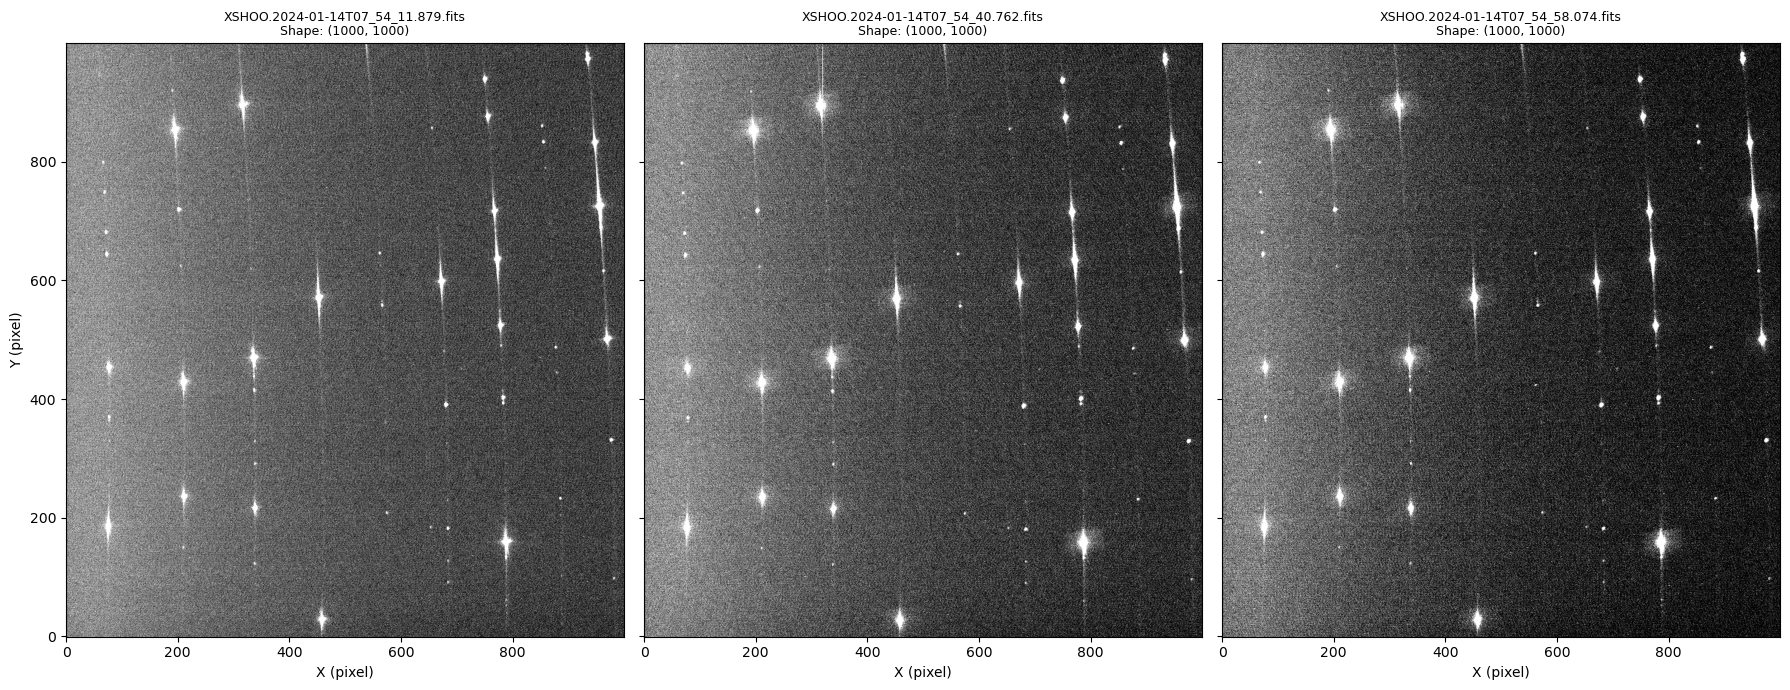

In [4]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize
import numpy as np

def plot_3_fits_tile(file1, file2, file3):
    files = [file1, file2, file3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)
    
    interval = ZScaleInterval()
    
    for i, (ax, fname) in enumerate(zip(axes, files)):
        with fits.open(fname) as hdul:
            # Recupera la prima estensione contenente un'immagine 2D
            data = None
            for hdu in hdul:
                if hdu.data is not None and len(hdu.data.shape) >= 2:
                    data = hdu.data
                    break
            
            if data is None:
                print(f"Attenzione: nessun dato 2D trovato in {fname}")
                continue
                
            if len(data.shape) == 3:
                data = data[0]

            # Calcola i livelli ZScale tipici di IRAF/DS9
            vmin, vmax = interval.get_limits(data)
            norm = ImageNormalize(data, vmin=vmin, vmax=vmax)

            im = ax.imshow(data, cmap='gray', origin='lower', norm=norm, aspect='auto')
            
            # Stampa dimensioni e nome
            ax.set_title(f"{fname.split('/')[-1]}\nShape: {data.shape}", fontsize=9)
            ax.set_xlabel("X (pixel)")
            if i == 0:
                ax.set_ylabel("Y (pixel)")

    plt.tight_layout()
    plt.show()

# Esegui passando i tre file scientifici (o i frame di confronto)
plot_3_fits_tile(
    'XSHOO.2024-01-14T07_54_11.879.fits',
    'XSHOO.2024-01-14T07_54_40.762.fits',
    'XSHOO.2024-01-14T07_54_58.074.fits'
)